### Customer Segmentation and Marketing Strategies

This project focuses on customer segmentation based on purchasing behavior indicators such as Recency (the time since the last purchase), Frequency (the number of purchases), and Monetary Value (the amount spent). The goal is to gain a deeper understanding of each customer group in order to recommend appropriate marketing strategies that optimize outreach effectiveness, increase revenue, and enhance customer satisfaction.

In [ ]:
# !pip install pandas, numpy, seaborn, matplotlib, openpyxl,scikit-learn

In [ ]:
# Import libraries
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [29]:
# Load data
df = pd.read_excel('data.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Check whether all columns have the right form or not, which we can see  InvoiceDate has the right format of datetime64[ns]

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [31]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [32]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [33]:
len(df)

541909

In [34]:
# Count percentage of null value
null_percentage = (df.isnull().sum()/ len(df))* 100

CustomerID with 25% of null values we can get rid of it

In [35]:
df.dropna(inplace=True)

Check duplicated

In [36]:
df.duplicated().sum()

np.int64(5225)

In [37]:
df.drop_duplicates(inplace=True)

In [38]:
len(df)

401604

Choose only 20,000 samples from dataset with random_state=42 for reproduce

In [39]:
df_samples = df.sample(20000, random_state=42)
df_samples.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
84050,543359,22794,SWEETHEART WIRE MAGAZINE RACK,1,2011-02-07 14:16:00,7.95,16332.0,United Kingdom
312069,564336,21731,RED TOADSTOOL LED NIGHT LIGHT,3,2011-08-24 14:28:00,1.65,12748.0,United Kingdom
363834,568589,22357,KINGS CHOICE BISCUIT TIN,4,2011-09-28 10:27:00,4.25,17405.0,United Kingdom
168161,551014,22992,REVOLVER WOODEN RULER,12,2011-04-26 11:04:00,1.95,13209.0,United Kingdom
216938,555858,C2,CARRIAGE,1,2011-06-07 14:12:00,50.00,14911.0,EIRE
142105,548551,22722,SET OF 6 SPICE TINS PANTRY DESIGN,4,2011-04-01 08:56:00,3.95,14886.0,United Kingdom
431629,573666,21807,WHITE CHRISTMAS STAR DECORATION,25,2011-10-31 16:24:00,0.42,15977.0,United Kingdom
480476,577303,22556,PLASTERS IN TIN CIRCUS PARADE,6,2011-11-18 13:02:00,1.65,14390.0,United Kingdom
338197,566518,22667,RECIPE BOX RETROSPOT,1,2011-09-13 11:24:00,2.95,17779.0,United Kingdom
20219,538015,21745,GAOLERS KEYS DECORATIVE GARDEN,3,2010-12-09 12:49:00,3.75,13240.0,United Kingdom


RFM segmentation is a marketing analysis method that involves analyzing customer behavior based on three key factors: recency, frequency, and monetary value.

In [40]:
# ------------ R : Recency ------------------
#  How much time has elapsed since a customer’s last activity or transaction with the brand?

df_samples['InvoiceDate'] =  pd.to_datetime(df_samples['InvoiceDate'], format='%Y-%m-%d %H:%M:%S')

# Take the nearest day in InvoiceDate + 1
import datetime 
current_date = max(df_samples['InvoiceDate']) + datetime.timedelta(days=1)

In [41]:
# ------------ M : Monetary Value ------------------
# this factor reflects how much a customer has spent with the brand during a particular period of time
df_samples['TotalPay'] = df_samples['Quantity'] * df_samples['UnitPrice']

In [43]:
# ------------ F : Frequency ------------------
# How often has a customer transacted or interacted with the brand during a particular period of time? 

# Group by CustomerID with R, F, M

df_customers = df_samples.groupby(['CustomerID']).agg(
    {
        'InvoiceDate' : lambda x: (current_date - x.max()).days,
        'InvoiceNo': 'count',
        'TotalPay':'sum'
    }
) 


In [46]:
df_customers.rename(columns={'InvoiceDate':'Recency','InvoiceNo':'Frequency','TotalPay':'MonetaryValue'}, inplace=True)

In [47]:
df_customers.head(10)

,Recency,Frequency,MonetaryValue
CustomerID,,,
12347.0,2,7,111.14
12349.0,19,3,94.10
12352.0,36,4,337.70
12354.0,232,3,56.00
12355.0,214,1,75.00
12356.0,245,4,485.40
12357.0,33,11,805.10
12359.0,8,12,171.35
12360.0,52,9,323.30


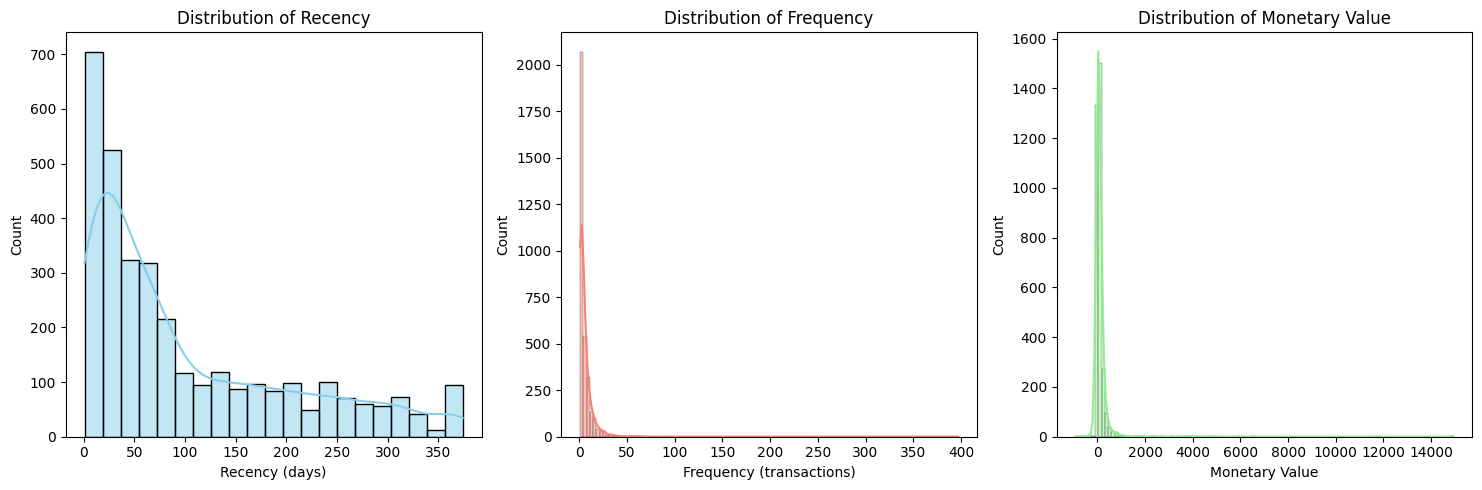

In [62]:
# Make chart to check 3 values
fig, ax = plt.subplots(1, 3, figsize=(15,5))

# Recency
sns.histplot(df_customers['Recency'], kde=True, color='skyblue', ax=ax[0])
ax[0].set_title('Distribution of Recency')
ax[0].set_xlabel('Recency (days)')
ax[0].set_ylabel('Count')

# Frequency
sns.histplot(df_customers['Frequency'], kde=True, color='salmon', ax=ax[1])
ax[1].set_title('Distribution of Frequency')
ax[1].set_xlabel('Frequency (transactions)')
ax[1].set_ylabel('Count')

# MonetaryValue
sns.histplot(df_customers['MonetaryValue'], kde=True, color='lightgreen', ax=ax[2])
ax[2].set_title('Distribution of Monetary Value')
ax[2].set_xlabel('Monetary Value')
ax[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


1. Recency
Most customers made a purchase recently (within 0-50 days), with the count around 700.

The distribution is right-skewed, meaning fewer customers have very long recency periods (over 200 days). 

The KDE curve (smooth line) overlays the histogram to show the overall density shape. On the Recency chart, the peak of the KDE line at approximately 0-50 days indicates that the majority of customers have made recent purchases.

2. Frequency

Most customers have a low frequency of transactions (mostly below 20).

The distribution is heavily right-skewed with a long tail, indicating a small number of customers transact very frequently (up to 400 times).

The KDE curve shows the density concentrated at low frequencies.

3. Monetary Value
Most customers have relatively low monetary values (under 2000).

The distribution is strongly right-skewed with a few customers spending very high amounts (up to 14,000+).

The KDE curve highlights the concentration of customers at lower spending levels.


In [76]:
# Analyse skewness and other transform like log, sqrt, Box-Cox
def analyse_skewness(x, data):
    fig, ax = plt.subplots(2, 2, figsize=(12,10))
    
    # Data
    sns.histplot(data[x], bins=30, color='skyblue', kde=True, ax=ax[0,0])
    sns.kdeplot(data[x], color='skyblue', bw_adjust=1.5, ax=ax[0,0], label='KDE')
    ax[0,0].set_title(f'Distribution of {x} (Original)')
    ax[0,0].legend()
    
    # Log transform
    log_data = np.log(data[x].replace(0, np.nan).dropna())  
    sns.histplot(log_data, bins=30, color='lightgreen', kde=True, ax=ax[0,1])
    sns.kdeplot(log_data, color='lightgreen', ax=ax[0,1], label='KDE')
    ax[0,1].set_title(f'Distribution of log({x})')
    ax[0,1].legend()
    
    # Square root transform
    sqrt_data = np.sqrt(data[x])
    sns.histplot(sqrt_data, bins=30, color='lightcoral', kde=True, ax=ax[1,0])
    sns.kdeplot(sqrt_data, color='lightcoral', ax=ax[1,0], label='KDE')
    ax[1,0].set_title(f'Distribution of sqrt({x})')
    ax[1,0].legend()
    
    # Box-Cox transform (data must be > 0)
    boxcox_data, _ = stats.boxcox(data[x] + 1)  
    sns.histplot(boxcox_data, bins=30, color='plum', kde=True, ax=ax[1,1])
    sns.kdeplot(boxcox_data, color='plum', ax=ax[1,1], label='KDE')
    ax[1,1].set_title(f'Distribution of Box-Cox({x})')
    ax[1,1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print skewness
    print(f"Skewness of original {x}: {data[x].skew().round(2)}")
    print(f"Skewness of log({x}): {log_data.skew().round(2)}")
    print(f"Skewness of sqrt({x}): {sqrt_data.skew().round(2)}")
    print(f"Skewness of Box-Cox({x}): {pd.Series(boxcox_data).skew().round(2)}")

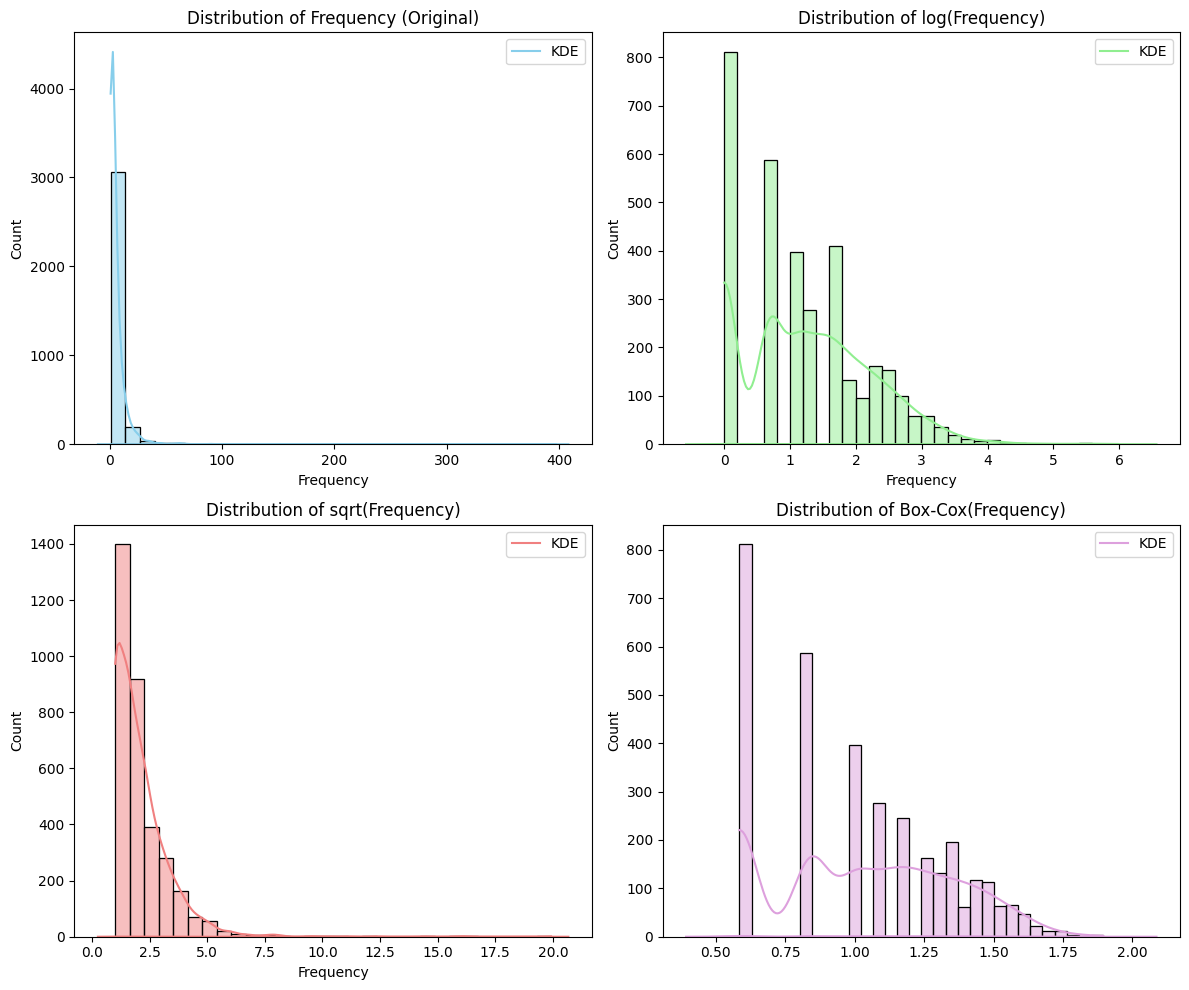

Skewness of original Frequency: 16.16
Skewness of log(Frequency): 0.53
Skewness of sqrt(Frequency): 3.43
Skewness of Box-Cox(Frequency): 0.13


In [77]:
analyse_skewness('Frequency', df_customers)

The original Frequency variable has a very large right-skewed distribution (skewness 16.16), making it unsuitable for direct use in models requiring a near-normal distribution.

Transformed variables (log, sqrt, Box-Cox) help reduce skewness, making the data distribution closer to normal, and increasing the efficiency of statistical and machine learning models.

Among these, the Box-Cox transform is the most effective method for balancing the distribution (skewness close to 0).

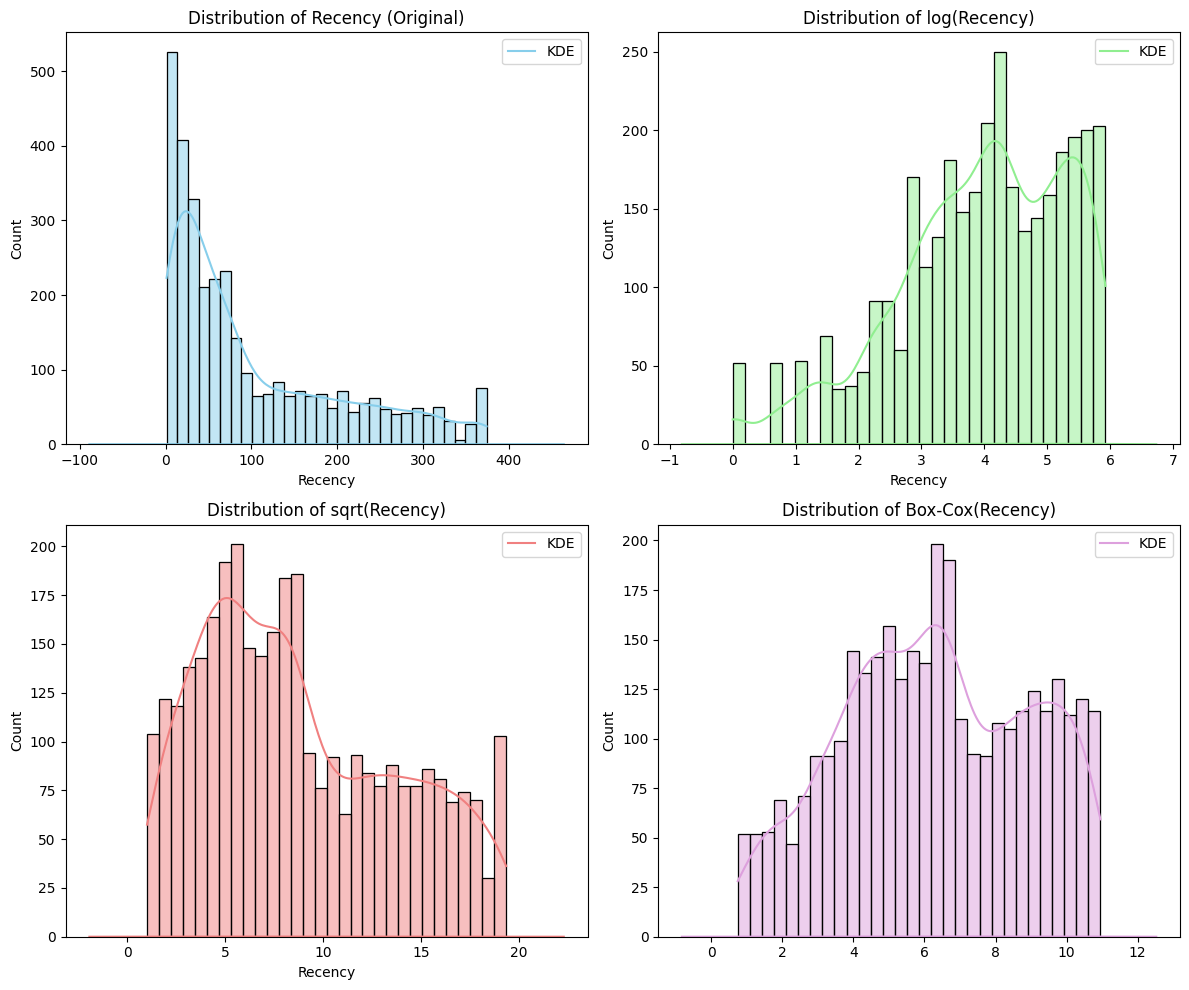

Skewness of original Recency: 1.12
Skewness of log(Recency): -0.69
Skewness of sqrt(Recency): 0.47
Skewness of Box-Cox(Recency): -0.07


In [78]:
analyse_skewness('Recency', df_customers)

The Box-Cox transform for Recency is the most effective method for balancing the distribution (skewness close to 0).

In [80]:
df_customers_t = pd.DataFrame()
df_customers_t['Recency'] = stats.boxcox(df_customers['Recency'])[0]
df_customers_t['Frequency'] = stats.boxcox(df_customers['Frequency'])[0]
df_customers_t['MonetaryValue'] = pd.Series(np.cbrt(df_customers['MonetaryValue'])).values
df_customers_t.head(10)

,Recency,Frequency,MonetaryValue
0,0.748672,1.558787,4.807915
1,4.139243,0.967190,4.548448
2,5.448859,1.181512,6.963758
3,10.505037,0.967190,3.825862
4,10.240354,0.000000,4.217163
5,10.686393,1.181512,7.858987
6,5.259565,1.828997,9.302863
7,2.635442,1.877773,5.554283
8,6.290012,1.712596,6.863336
9,11.225163,0.000000,2.545822


Because MonetaryValue contain negative value so transform to cubic root values

In [ ]:
# Scale data using StandardScaler

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_customers_t = scaler.fit_transform(df_customers_t)

In [85]:
pd.DataFrame(df_customers_t).head()


,0,1,2
0,-1.938970,0.816284,0.445562
1,-0.839096,-0.014900,0.323659
2,-0.414267,0.286220,1.458423
3,1.225917,-0.014900,-0.015827
4,1.140056,-1.373786,0.168014


`kmeans.inertia_` : The sum of squared errors (SSE) from each point to the nearest cluster center is used as an indicator to assess cluster quality.

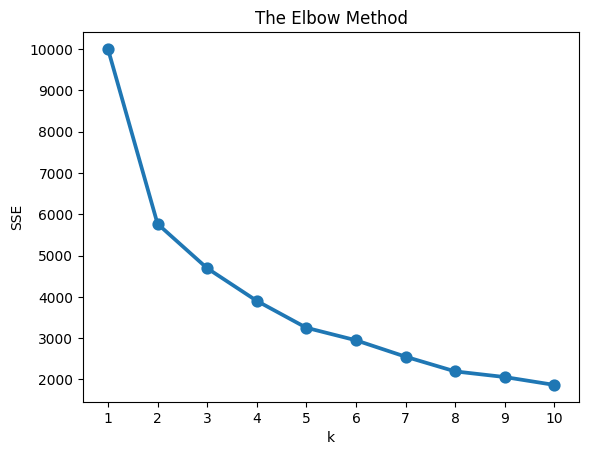

In [86]:
# Using KNN 
from sklearn.cluster import KMeans

sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_customers_t)
    sse[k] = kmeans.inertia_ 
    
plt.title('The Elbow Method')
plt.xlabel('k')
plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

Choose k = 3 or 2 and fit with the data

In [95]:
model = KMeans(n_clusters=3, random_state=42)
model.fit(df_customers_t)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [96]:
df_customers['Cluster'] = model.labels_
df_customers.head()

,Recency,Frequency,MonetaryValue,Cluster
CustomerID,,,,
12347.0,2,7,111.14,1
12349.0,19,3,94.10,0
12352.0,36,4,337.70,1
12354.0,232,3,56.00,2
12355.0,214,1,75.00,2


In [97]:
df_customers.groupby('Cluster').agg(
    {
        'Recency':'mean',
        'Frequency':'mean',
        'MonetaryValue':'mean'
    }
).round(2)

,Recency,Frequency,MonetaryValue
Cluster,,,
0,56.17,4.33,59.71
1,28.63,17.03,408.81
2,191.68,1.68,29.68


Group 0 : These customers made purchases relatively recently (average recency ~56 days), with a moderate frequency of purchase (~4.3 times), and a low to medium average spending value (~60). This could be considered an average customer group, not overly frequent but still active.

Group 1 : These customers made purchases very recently (lowest Recency ~29 days), purchased very frequently (high Frequency ~17 times), and spent a large amount (high Monetary Value ~409). This is a highly loyal and valuable customer group, the best customer segment.

Group 2 : These customers haven't purchased in a long time (very high recency, approximately 192 days), have a very low purchase frequency (approximately 1.7 times), and low spending (approximately 30). This could be a group of customers who are no longer active or have little interest.

### Recommendation for Marketing Strategy

Group 1 consists of high-value customers who are frequent and recent buyers, so priority should be given to nurturing and retaining them.

+ Special care: Offer special deals, vouchers, and loyalty programs to retain and increase customer loyalty.
+ Upsell & Cross-sell: Introduce related products/services to increase order value.
+ Early announcements: Send promotional information and new product launches early to create a sense of exclusivity.



Group 0 is a group of average customers who can be further developed to increase frequency and value.

+ Promotional offers to stimulate purchases: Send discount coupons, buy-one-get-one-free programs to increase purchase frequency.

+ Increase engagement: Send reminder emails, product news, and engaging content to maintain interest.

+ Referral programs: Encourage them to refer new people to expand the customer base.

Group 2 is a group of customers that need to be reactivated 

+ Reactivation campaign: Send emails and SMS messages with attractive offers and big discounts to entice them to return.
+ Do survey: Ask for feedback to understand why they didn't buy, and then adjust the product/service accordingly.
